In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
path_to_data = '../../data/broader_context/chem/'
path_to_final_figures = '../../../paper/final_figures/'

In [36]:
alhic1901_IC = pd.read_csv('../../data/sampling/master/ic_icpms_master.csv')

# rename
rename_map = {
    "section": "Section",
    "top_depth": "Top Depth (m)",
    "bottom_depth": "Bot Depth (m)",
    "Cl-": "Cl- (µg/L)",
    "NO3-": "NO3- (µg/L)",
    "SO42-": "SO42- (µg/L)",
    "Na+": "Na+ (µg/L)",
    "K+": "K+ (µg/L)",
    "Mg2+": "Mg2+ (µg/L)",
    "Ca2+": "Ca2+ (µg/L)"
}
alhic1901_IC = alhic1901_IC.rename(columns=rename_map)

# Keep only columns that match the ALHIC1901 IC schema
keep_cols = [col for col in alhic1901_IC.columns if col in alhic1901_IC.columns]
alhic1901_myIC = alhic1901_IC[keep_cols].copy()

In [37]:
#alhic1901_IC = pd.read_csv(path_to_data+'ALHIC1901_MajorIons.csv')
alhic1903_IC = pd.read_csv(path_to_data+'ALHIC1903_MajorIons.csv')
alhic1901_ICPMS = pd.read_csv(path_to_data+'ALHIC1901_TraceElements.csv')
alhic1903_ICPMS = pd.read_csv(path_to_data+'ALHIC1903_TraceElements.csv')

In [38]:
def add_ion_balance(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add an ion_balance column to a major-ion dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing major ion concentration columns:
        Cl- (µg/L), NO3- (µg/L), SO42- (µg/L), Na+ (µg/L),
        K+ (µg/L), Mg2+ (µg/L), Ca2+ (µg/L)

    Returns
    -------
    pd.DataFrame
        Copy of the input dataframe with a new column:
        ion_balance = anion - cation
    """
    out = df.copy()

    # Convert from micrograms per liter to grams per liter
    ug_per_l_to_g_per_l = 1e-6

    cl_mol = (out["Cl- (µg/L)"] * ug_per_l_to_g_per_l) / 35.45
    na_mol = (out["Na+ (µg/L)"] * ug_per_l_to_g_per_l) / 22.99
    ca_mol = (out["Ca2+ (µg/L)"] * ug_per_l_to_g_per_l) / 40.08
    so4_mol = (out["SO42- (µg/L)"] * ug_per_l_to_g_per_l) / 96.06
    mg_mol = (out["Mg2+ (µg/L)"] * ug_per_l_to_g_per_l) / 24.305
    no3_mol = (out["NO3- (µg/L)"] * ug_per_l_to_g_per_l) / 62.01
    k_mol = (out["K+ (µg/L)"] * ug_per_l_to_g_per_l) / 39.10

    # Match the MATLAB handling used for ION1903:
    # negative K values are treated as missing
    k_mol = k_mol.mask(k_mol < 0)

    anion = 2 * so4_mol + no3_mol + cl_mol
    cation = 2 * ca_mol + 2 * mg_mol + k_mol + na_mol

    out["ion_balance"] = anion - cation

    return out

In [39]:
# impliment function to add ion balance to both dataframes
alhic1901_IC = add_ion_balance(alhic1901_IC)
alhic1903_IC = add_ion_balance(alhic1903_IC)

In [40]:
# add a column called 'glacial' or 'interglacial' to the ALHIC1903 dataframe. Assign to MIS5e or MIS6 based on the 'Age_ka' column
mis5e_mask = alhic1903_IC["Age (ka)"].between(115, 128.3, inclusive="both")
mis6_mask = alhic1903_IC["Age (ka)"].between(134.4, 191, inclusive="both")

alhic1903_IC["glacial_interglacial"] = pd.NA
alhic1903_IC.loc[mis5e_mask, "glacial_interglacial"] = "interglacial"
alhic1903_IC.loc[mis6_mask, "glacial_interglacial"] = "glacial"

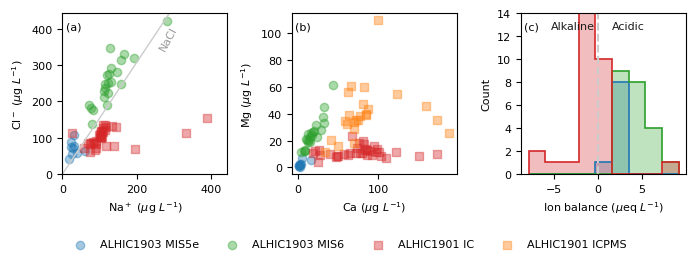

In [41]:
# Make the plot
from shapely import transform


plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Colors and markers
color_1903_mis5e = "#1f77b4"
color_1903_mis6 = "#2ca02c"
color_1901_ic = "#d62728"
color_1901_icpms = "#ff7f0e"
marker_1903 = "o"
marker_1901 = "s"
point_alpha = 0.4

# Prepare ion balance data (microeq/L)
ion_1901 = (alhic1901_IC["ion_balance"] * 1e6).dropna()
ion_1903_mis5e = (alhic1903_IC.loc[mis5e_mask, "ion_balance"] * 1e6).dropna()
ion_1903_mis6 = (alhic1903_IC.loc[mis6_mask, "ion_balance"] * 1e6).dropna()
all_ion = pd.concat([ion_1901, ion_1903_mis5e, ion_1903_mis6], ignore_index=True)
bins = np.histogram_bin_edges(all_ion, bins="auto")

# Prepare IC data for Cl and Na (ug/L)
cl_1901 = alhic1901_IC["Cl- (µg/L)"]
na_1901 = alhic1901_IC["Na+ (µg/L)"]
cl_1903 = alhic1903_IC["Cl- (µg/L)"]
na_1903 = alhic1903_IC["Na+ (µg/L)"]

# Prepare Mg and Ca data (IC + ICPMS) (ug/L)
mg_1901_ic = alhic1901_IC["Mg2+ (µg/L)"]
ca_1901_ic = alhic1901_IC["Ca2+ (µg/L)"]
mg_1903_ic = alhic1903_IC["Mg2+ (µg/L)"]
ca_1903_ic = alhic1903_IC["Ca2+ (µg/L)"]

mg_1901_icpms = alhic1901_ICPMS["Mg (ug/L)"]
ca_1901_icpms = alhic1901_ICPMS["Ca (ug/L)"]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
ax1, ax2, ax3 = axes

# Subplot 1: Na vs Cl (IC)
ax1.scatter(na_1903[mis5e_mask], cl_1903[mis5e_mask], color=color_1903_mis5e, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS5e")
ax1.scatter(na_1903[mis6_mask], cl_1903[mis6_mask], color=color_1903_mis6, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS6")
ax1.scatter(na_1901, cl_1901, color=color_1901_ic, marker=marker_1901, alpha=point_alpha, label="ALHIC1901 IC")

max_val = np.nanmax(pd.concat([na_1901, cl_1901, na_1903, cl_1903], ignore_index=True))
ax1.plot([0, max_val], [0, max_val * 1.54], color="0.8", linewidth=1)
ax1.set_xlim(0, max_val * 1.05)
ax1.set_ylim(0, max_val * 1.05)
ax1.set_xlabel(r"Na$^+$ ($\mu$g $L^{-1}$)")
ax1.set_ylabel(r"Cl$^-$ ($\mu$g $L^{-1}$)")
ax1.text(0.02, 0.95, "(a)", transform=ax1.transAxes, ha="left", va="top")

# Label NaCl line
p1 = ax1.transData.transform((0, 0))
p2 = ax1.transData.transform((1, 1))
angle = np.degrees(np.arctan2(p2[1] * 1.54 - p1[1] * 1.54, p2[0] - p1[0]))
ax1.text(max_val * 0.65, max_val * 0.8, "NaCl", color="0.6", rotation=angle, rotation_mode="anchor")

# Subplot 2: Ca vs Mg (IC + ICPMS)
ax2.scatter(ca_1903_ic[mis5e_mask], mg_1903_ic[mis5e_mask], color=color_1903_mis5e, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS5e")
ax2.scatter(ca_1903_ic[mis6_mask], mg_1903_ic[mis6_mask], color=color_1903_mis6, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS6")
ax2.scatter(ca_1901_ic, mg_1901_ic, color=color_1901_ic, marker=marker_1901, alpha=point_alpha, label="ALHIC1901 IC")
ax2.scatter(ca_1901_icpms, mg_1901_icpms, color=color_1901_icpms, marker=marker_1901, alpha=point_alpha, label="ALHIC1901 ICPMS")
ax2.set_xlabel(r"Ca ($\mu$g $L^{-1}$)")
ax2.set_ylabel(r"Mg ($\mu$g $L^{-1}$)")
ax2.text(0.02, 0.95, "(b)", transform=ax2.transAxes, ha="left", va="top")

# Subplot 3: Ion balance histogram
histo_alpha = 0.3
ax3.hist(ion_1903_mis5e, bins=bins, color=color_1903_mis5e, alpha=histo_alpha, label="ALHIC1903 MIS5e")
ax3.hist(ion_1903_mis6, bins=bins, color=color_1903_mis6, alpha=histo_alpha, label="ALHIC1903 MIS6")
ax3.hist(ion_1901, bins=bins, color=color_1901_ic, alpha=histo_alpha, label="ALHIC1901 IC")
ax3.hist(ion_1903_mis5e, bins=bins, histtype="step", color=color_1903_mis5e, linewidth=1.2)
ax3.hist(ion_1903_mis6, bins=bins, histtype="step", color=color_1903_mis6, linewidth=1.2)
ax3.hist(ion_1901, bins=bins, histtype="step", color=color_1901_ic, linewidth=1.2)
ax3.set_xlabel(r"Ion balance ($\mu$eq $L^{-1}$)")
ax3.set_ylabel("Count")
ax3.text(0.02, 0.95, "(c)", transform=ax3.transAxes, ha="left", va="top")

# add a vertical dashed line at zero with a alkaline and acidic label on either side
ax3.set_ylim(0,14)
ax3.axvline(0, color="0.8", linestyle="--")
ax3.text(0.45, 0.95, "Alkaline", transform  =ax3.transAxes, ha="right", va="top", color="0.1")
ax3.text(0.55, 0.95, "Acidic", transform    =ax3.transAxes, ha="left", va="top", color="0.1")

# One legend centered below all subplots
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05))

fig.tight_layout()

# save final figure as pdf and png
fig.savefig(path_to_final_figures + 'pdf/chemistry_compare.pdf', dpi=300)
fig.tight_layout(rect=[0, 0.08, 1, 1])

# overwrite both files including legend area
fig.savefig(path_to_final_figures + "pdf/chemistry_compare.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
fig.savefig(path_to_final_figures + "png/chemistry_compare.png", dpi=300, bbox_inches="tight", pad_inches=0.05)

plt.show()
